In [44]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

IMAGE_WIDTH = 160
IMAGE_HEIGHT = 32

DATASET_PATH = "/kaggle/input/datasets/hoangvudinh0301/rcnn-dataset/full_plate_dataset"

CHARACTERS = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"

VOCAB_SIZE = len(CHARACTERS) + 1   # +1 for CTC blank
BLANK_INDEX = VOCAB_SIZE - 1

char_to_num = {c:i for i,c in enumerate(CHARACTERS)}
num_to_char = {i:c for i,c in enumerate(CHARACTERS)}

def load_image(path):

    img = cv2.imread(path,0)

    img = cv2.resize(img,(IMAGE_WIDTH,IMAGE_HEIGHT))

    img = img.astype("float32") / 255.0

    img = np.expand_dims(img,-1)

    return img

def encode_label_from_filename(filename):

    label = os.path.splitext(filename)[0]

    label = label.split("_")[0]

    label = label.upper()

    return [char_to_num[c] for c in label if c in char_to_num]


images = []
labels = []

for file in os.listdir(DATASET_PATH):

    if file.endswith(".jpg") or file.endswith(".png"):

        img_path = os.path.join(DATASET_PATH,file)

        img = load_image(img_path)

        encoded = encode_label_from_filename(file)

        images.append(img)
        labels.append(encoded)

X = np.array(images)

y = pad_sequences(labels,padding="post",value=BLANK_INDEX)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

def build_crnn():

    input_img = layers.Input(shape=(IMAGE_HEIGHT,IMAGE_WIDTH,1))

    x = layers.Conv2D(64,3,padding="same",activation="relu")(input_img)
    x = layers.MaxPool2D(2,2)(x)

    x = layers.Conv2D(128,3,padding="same",activation="relu")(x)
    x = layers.MaxPool2D(2,2)(x)

    x = layers.Conv2D(256,3,padding="same",activation="relu")(x)

    x = layers.Conv2D(256,3,padding="same",activation="relu")(x)
    x = layers.MaxPool2D((2,1))(x)

    x = layers.Conv2D(512,3,padding="same",activation="relu")(x)
    x = layers.BatchNormalization()(x)

    x = layers.Conv2D(512,3,padding="same",activation="relu")(x)
    x = layers.MaxPool2D((2,1))(x)

    x = layers.Conv2D(512,2,activation="relu")(x)

    x = layers.Reshape((-1,512))(x)

    x = layers.Bidirectional(layers.LSTM(256,return_sequences=True))(x)
    x = layers.Bidirectional(layers.LSTM(256,return_sequences=True))(x)

    output = layers.Dense(VOCAB_SIZE,activation="softmax")(x)

    model = Model(inputs=input_img,outputs=output)

    return model

def ctc_loss(y_true, y_pred):
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    

    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")

    label_length = tf.reduce_sum(tf.cast(tf.not_equal(y_true, -1), dtype="int64"), axis=1, keepdims=True)
    
    y_true_cleaned = tf.where(tf.equal(y_true, -1), tf.zeros_like(y_true), y_true)

    loss = tf.keras.backend.ctc_batch_cost(
        y_true_cleaned,
        y_pred,
        input_length,
        label_length
    )
    return loss
model = build_crnn()

model.compile(
    optimizer="adam",
    loss=ctc_loss
)

model.summary()

model.fit(
    X_train,
    y_train,
    validation_data=(X_val,y_val),
    batch_size=16,
    epochs=50
)



Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 32, 160, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 32, 160, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 80, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 40, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 8, 40, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 8, 40, 256)     │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 4, 40, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 4, 40, 512)     │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 4, 40, 512)     │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 4, 40, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 2, 40, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 1, 39, 512)     │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_5 (Reshape)             │ (None, 39, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 39, 512)        │     1,574,912 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 39, 512)        │     1,574,912 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 39, 37)         │        18,981 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,719,653 (33.26 MB)

 Trainable params: 8,718,629 (33.26 MB)

 Non-trainable params: 1,024 (4.00 KB)

Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 17s 49ms/step - loss: 27.4141 - val_loss: 21.8208
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 20.7880 - val_loss: 20.5402
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 19.7253 - val_loss: 19.6914
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - loss: 19.2066 - val_loss: 20.3187
Epoch 5/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 17.1975 - val_loss: 13.1687
Epoch 6/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 10.4999 - val_loss: 8.7014
Epoch 7/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 7.3389 - val_loss: 7.3994
Epoch 8/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 6.5812 - val_loss: 7.0095
Epoch 9/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 6.1091 - val_loss: 6.2539
Epoch 10/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 5.2884 - val_loss: 6.1487
Epoch 11/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 5.0884 - val_loss: 5.9486
Epoch 12/50
214/214

In [45]:
def decode_prediction(pred):
    batch_size = pred.shape[0]
    input_len = np.ones(batch_size) * pred.shape[1]

    results = tf.keras.backend.ctc_decode(
        pred, 
        input_length=input_len, 
        greedy=True
    )[0][0]

    decoded_strings = []

    for i in range(batch_size):
        res = results[i].numpy()

        chars = [num_to_char[int(r)] for r in res if r != -1]
        
        decoded_strings.append("".join(chars))
        
    return decoded_strings

In [50]:
def calculate_accuracy(model, X, y_true):

    preds = model.predict(X, batch_size=16, verbose=1)
    
    decoded_preds = decode_prediction(preds)

    decoded_true = []

    for label in y_true:
        chars = [num_to_char[int(c)] for c in label if int(c) != BLANK_INDEX]
        decoded_true.append("".join(chars))

    correct = 0
    for p, t in zip(decoded_preds, decoded_true):
        if p.strip() == t.strip():
            correct += 1

    acc = correct / len(decoded_true)
    print(f"\nOverall Accuracy: {acc * 100:.2f}%")
    return acc

In [51]:
train_acc = calculate_accuracy(model,X_train,y_train)
val_acc = calculate_accuracy(model,X_val,y_val)

print("Train Accuracy:",train_acc)
print("Validation Accuracy:",val_acc)

214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step

Overall Accuracy: 97.52%
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

Overall Accuracy: 59.70%
Train Accuracy: 0.9751534638994446
Validation Accuracy: 0.5969626168224299


In [29]:
model.save("crnn_plate_reader_3.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


['19A08564']

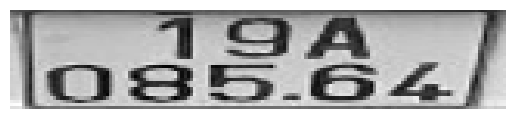

In [56]:
import matplotlib.pyplot as plt

def predict_plate(image_path):

    img = load_image(image_path)

    plt.imshow(np.squeeze(img), cmap='gray')
    plt.axis('off')
    
    img = np.expand_dims(img, axis=0)
    pred = model.predict(img)

    plate = decode_prediction(pred)

    return plate

predict_plate("/kaggle/input/datasets/hoangvudinh0301/rcnn-dataset/full_plate_dataset/19A08564_2920.png")